<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/002_runtime_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

!pip install -q "jax[cuda12]==0.6.0" "jaxlib==0.6.0" optax tensorflow-probability

import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import optax
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import time

import utils
from core import EIV

Cloning into 'error-in-variables-garon-2026'...
remote: Enumerating objects: 307, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 307 (delta 66), reused 0 (delta 0), pack-reused 179 (from 1)
Receiving objects: 100% (307/307), 12.28 MiB | 32.15 MiB/s, done.
Resolving deltas: 100% (172/172), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.4/123.4 MB 21.5 MB/s eta 0:00:00


In [2]:
# KEY DUMP
GEN_KEY = jax.random.PRNGKey(8)
INIT_KEY = jax.random.PRNGKey(11)
OPT_KEY = jax.random.PRNGKey(123)
TEST_KEY = jax.random.PRNGKey(777)

# Small Simulation: N = 100, T = 3000


### Simulate Data

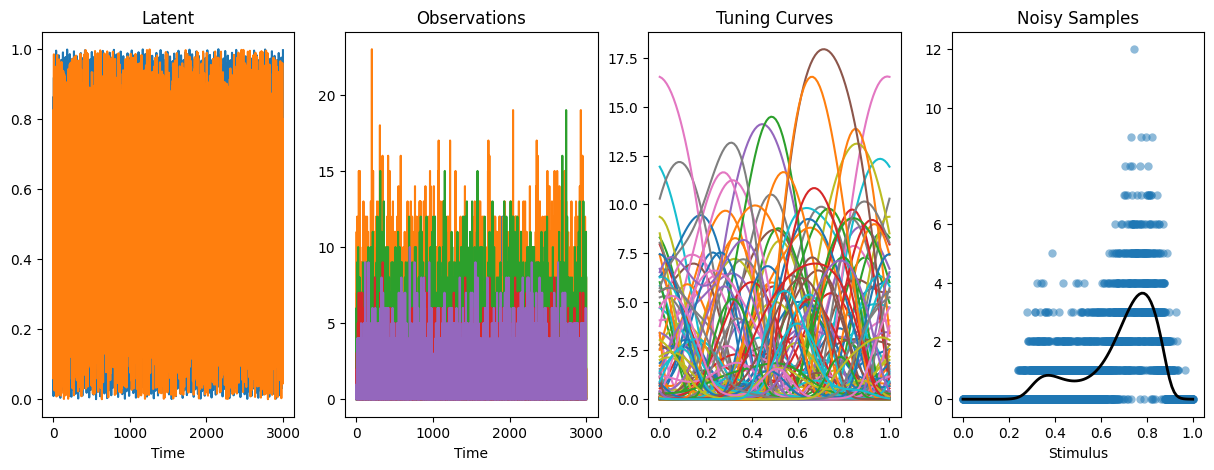

In [3]:
# Generative Hyperparams
num_neurons = 100
num_dims = 1
num_steps = 3000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, y_and_s = model.simulate(
    num_steps=num_steps
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, y_and_s, model);

### Fit Model

In [4]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":5e-4,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
    }

start_time = time.perf_counter()

model.fit(y_and_s, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()

print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Very small (N=", num_neurons, "T=",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")




 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Very small (N= 100 T= 3000
|-----|------------------------------------------:|
| EIV |  3.379478066000047  secs


### Plot Results

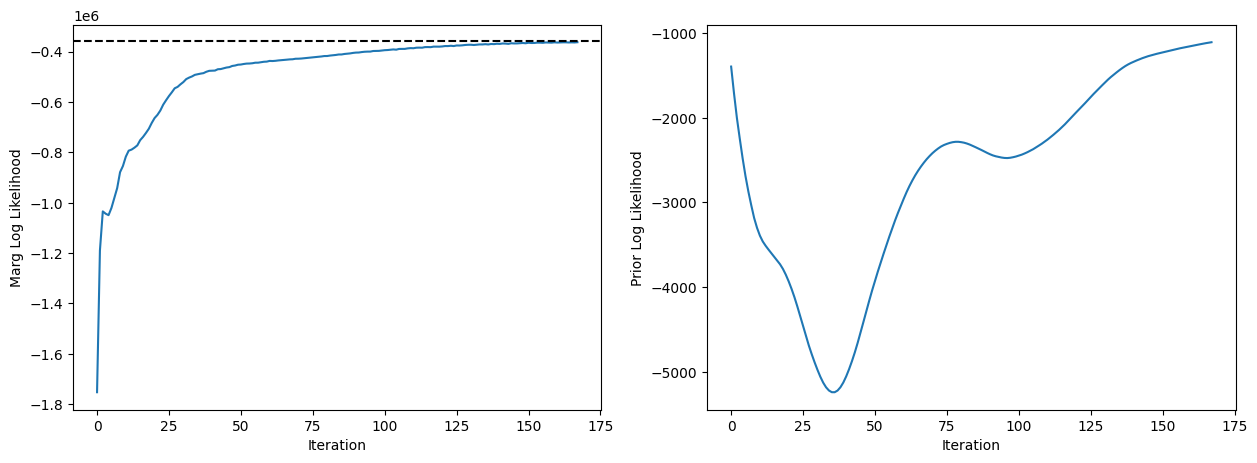

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


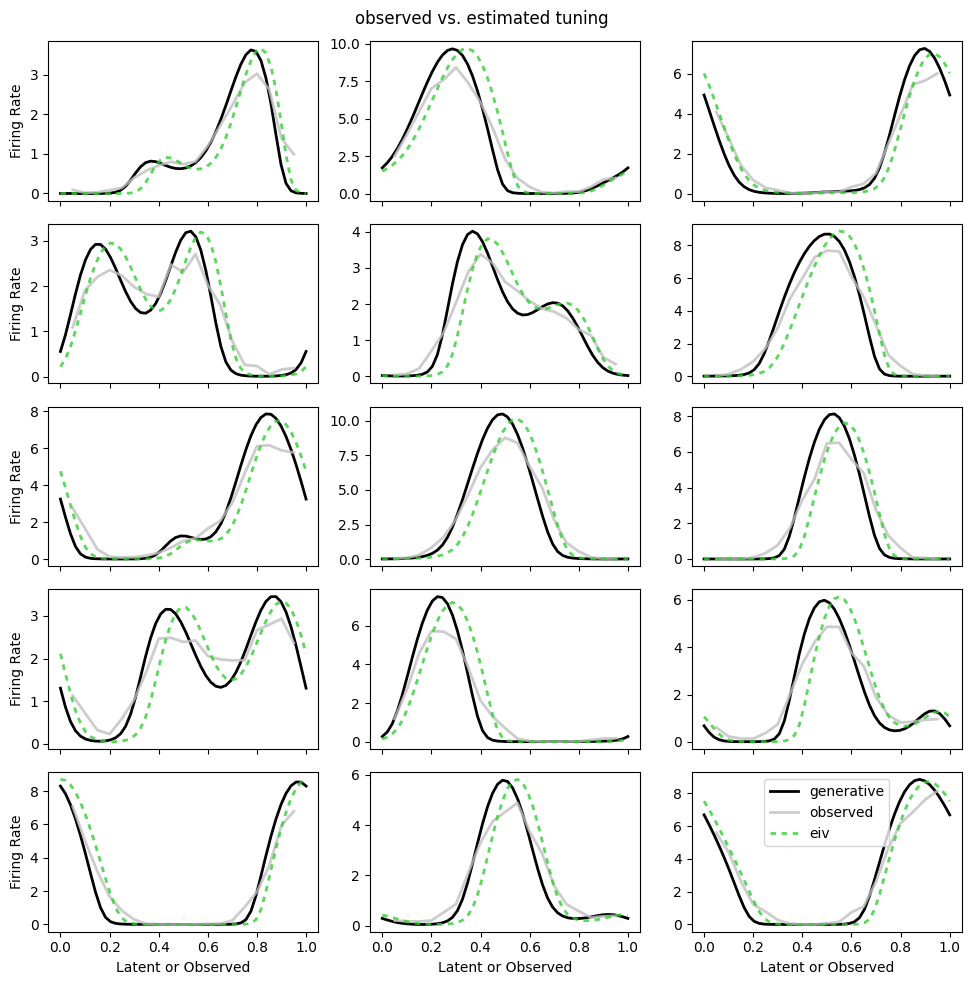

In [5]:
utils.plot_objhist_sim(model, y_and_s, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, y_and_s, grid_max = 1, grid_reso=50);


# Medium Simulation: N = 250, T = 72000

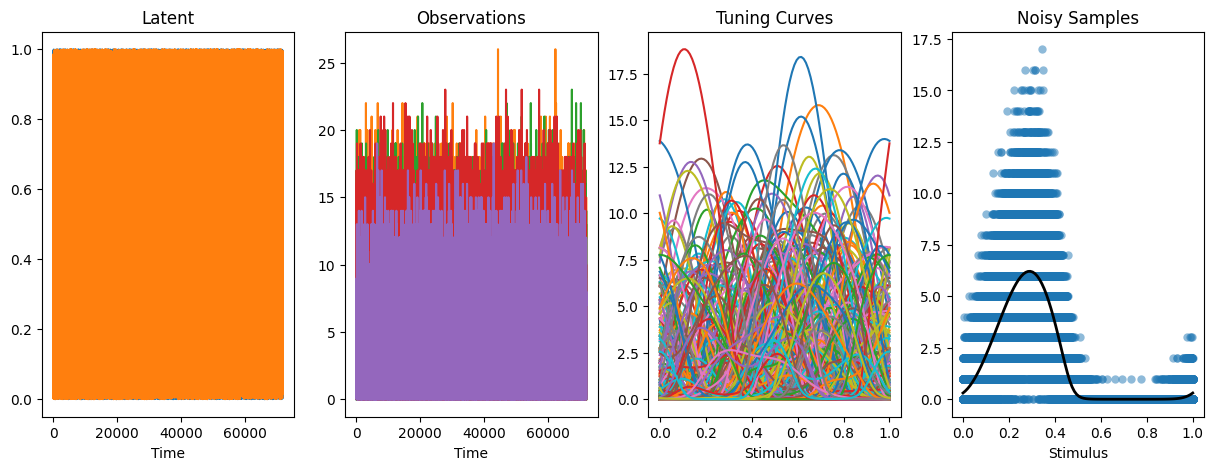

In [6]:
# Generative Hyperparams
num_neurons = 250
num_dims = 1
num_steps = 72000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, y_and_s = model.simulate(
    num_steps=num_steps
)

# Visualize Data
utils.plot_simulated_data_1D(xs_true, model.true_params, y_and_s, model);

### Fit Model

In [7]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-4,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
}

start_time = time.perf_counter()

model.fit(y_and_s, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()

print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Medium (N =", num_neurons, "T =",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")




 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Medium (N = 250 T = 72000
|-----|------------------------------------------:|
| EIV |  3.782685367999875  secs


### Plot Results

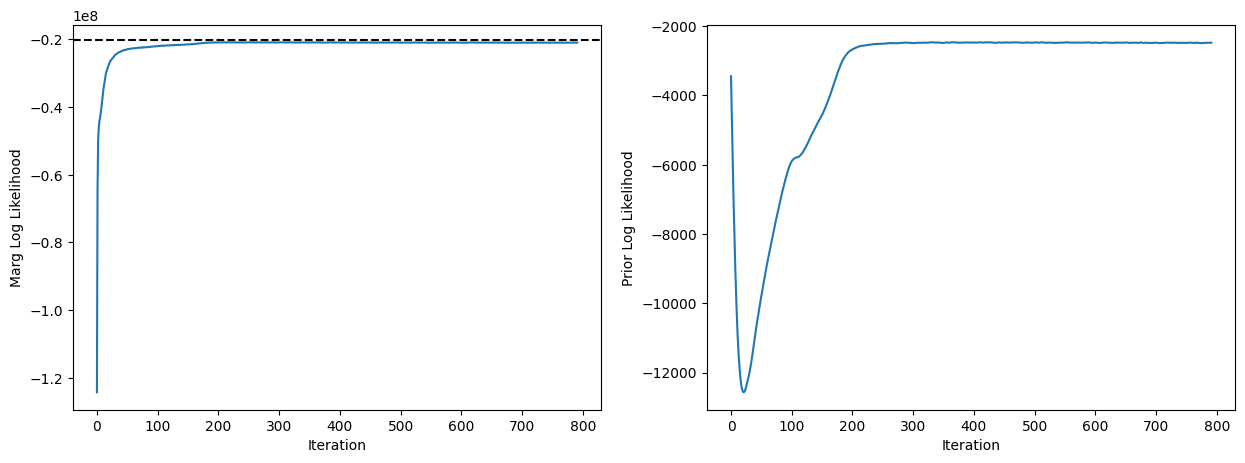

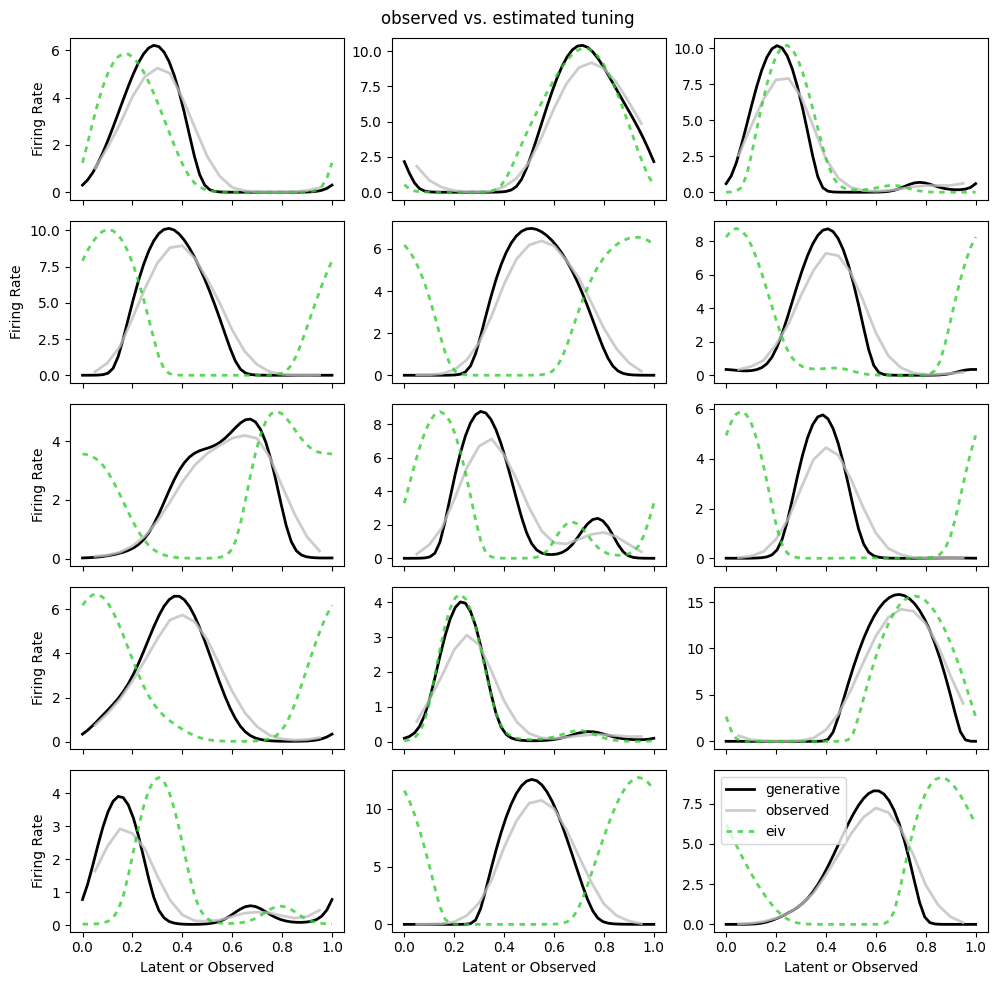

In [8]:
utils.plot_objhist_sim(model, y_and_s, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, y_and_s, grid_max = 1, grid_reso=50);



# Large Simulation: N = 600, T = 500000

In [9]:
# Generative Hyperparams
num_neurons = 600
num_dims = 1
num_steps = 500000

# Construct Model
model = EIV(len_scale = .2,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons)

# Simulate Data
xs_true, y_and_s = model.simulate(
    num_steps=num_steps
)

### Fit Model

In [10]:
# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-3,
        "minibatch":True,
        "batch_size":1000,
        "lr": 1e0
    }

start_time = time.perf_counter()

model.fit(y_and_s, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()


print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Large (N =", num_neurons, "T =",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")





 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Large (N = 600 T = 500000
|-----|------------------------------------------:|
| EIV |  7.764140116999897  secs


### Plot Results

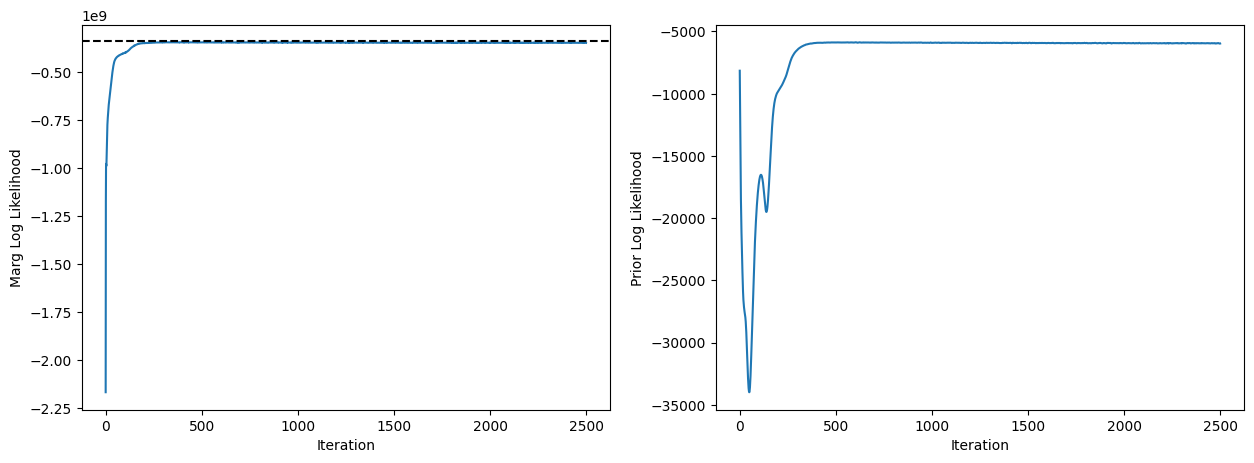

In [ ]:
utils.plot_objhist_sim(model, y_and_s, TEST_KEY)

x_grid = jnp.linspace(0, 1, 50)[:, None]
true_tunings = model.observation.mapping(model.true_params, x_grid)[0].T
utils.plot_real_tuning(model, true_tunings, y_and_s, grid_max = 1, grid_reso=50);
